# Feature Engineering Pipeline — Network Traffic Dataset

**Goal:** Transform the cleaned network-flow dataset into DNN-ready features.  
**Input:** `../data/processed/cleaned_traffic_data.csv`  
**Output:** `../data/processed/traffic_features_engineered.csv`

---

| Step | Action | Rationale |
|------|--------|-----------|
| 1 | `has_active_idle` binary flag | Preserve structural information before log transform |
| 2 | Feature engineering (5 derived columns) | Strengthen traffic-type separability |
| 3 | `log1p` normalisation | Compress heavy-tailed distributions before scaling |
| 4 | Data cleaning (negatives, inf, NaN, duplicates) | Ensure data quality |
| 5 | One-hot encoding | Model compatibility |
| 6 | StandardScaler normalisation | Zero-mean / unit-variance for DNN stability |
| 7 | Export | Persist DNN-ready dataset |
| 8 | Quick validation — derived feature distributions | Sanity check |


## 1. Imports & Configuration

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

DATA_PATH   = "../data/processed/cleaned_traffic_data.csv"
OUTPUT_PATH = "../data/processed/traffic_features_engineered.csv"

print("Libraries loaded.")

Libraries loaded.


## 2. Data Loading & Target Column Detection

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Input shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

_target_candidates = {"target", "label", "class", "sonuc", "durum"}
target_column = next(
    (col for col in df.columns if col.lower() in _target_candidates),
    df.columns[-1]
)
print(f"Target column : '{target_column}'")
print(f"\nClass distribution:")
print(df[target_column].value_counts())

Input shape : 40,987 rows × 24 columns
Target column : 'traffic_type'

Class distribution:
traffic_type
VPN-BROWSING     7317
BROWSING         6459
VOIP             6344
VPN-VOIP         5335
VPN-FT           3336
VPN-CHAT         2178
FT               2146
CHAT             2127
P2P              1950
VPN-STREAMING     835
MAIL              828
VPN-P2P           792
STREAMING         749
VPN-MAIL          591
Name: count, dtype: int64


## 3. `has_active_idle` Binary Flag

A value of `-1` in `min_active` or `min_idle` indicates that no active / idle window was observed for that flow.  
This structural difference would be lost after the log transform, so it is captured as a binary flag first.

```
has_active_idle = 0  →  no window observed  (min_active == -1  OR  min_idle == -1)
has_active_idle = 1  →  window observed
```


In [3]:
_required = {"min_active", "min_idle"}

if _required.issubset(df.columns):
    df["has_active_idle"] = np.where(
        (df["min_active"] == -1) | (df["min_idle"] == -1), 0, 1
    )
    n0 = (df["has_active_idle"] == 0).sum()
    n1 = (df["has_active_idle"] == 1).sum()
    print(f"has_active_idle  →  0 (no window): {n0:,}  |  1 (window present): {n1:,}")
else:
    missing = _required - set(df.columns)
    print(f"Warning: columns not found, flag skipped: {missing}")

has_active_idle  →  0 (no window): 0  |  1 (window present): 40,987


## 4. Feature Engineering

Five derived features are added to strengthen traffic-type separability.

| New Column | Formula | What It Measures |
|---|---|---|
| `bytes_per_pkt` | `flowBytes / (flowPkts + ε)` | Payload per packet (MAIL ≈ 80, STREAMING ≈ 1250) |
| `iat_cv` | `std_iat / (mean_iat + 1)` | Packet-arrival irregularity (VOIP ≈ 0.8, P2P ≈ 6–15) |
| `symmetry_index` | `(fiat − biat) / (fiat + biat + 1)` | Traffic directionality (MAIL ≈ 0.52, VPN ≈ 0.01) |
| `active_idle_ratio` | `mean_active / (mean_idle + 1)` | Connection intensity (VOIP ≈ 0.16, BROWSING ≈ 0.82) |
| `log_duration` | `log1p(duration)` | Compressed representation of flow duration |


In [4]:
_fe_log = []

def _add_feature(name, condition_cols, formula_fn):
    if set(condition_cols).issubset(df.columns):
        df[name] = formula_fn()
        _fe_log.append(f"OK    {name}")
    else:
        _fe_log.append(f"SKIP  {name}  —  missing columns: {set(condition_cols) - set(df.columns)}")

_add_feature(
    "bytes_per_pkt",
    ["flowBytesPerSecond", "flowPktsPerSecond"],
    lambda: df["flowBytesPerSecond"] / (df["flowPktsPerSecond"] + 1e-6),
)
_add_feature(
    "iat_cv",
    ["std_flowiat", "mean_flowiat"],
    lambda: df["std_flowiat"] / (df["mean_flowiat"] + 1),
)
_add_feature(
    "symmetry_index",
    ["total_fiat", "total_biat"],
    lambda: (df["total_fiat"] - df["total_biat"]) / (df["total_fiat"] + df["total_biat"] + 1),
)
_add_feature(
    "active_idle_ratio",
    ["mean_active", "mean_idle"],
    lambda: df["mean_active"] / (df["mean_idle"] + 1),
)
_add_feature(
    "log_duration",
    ["duration"],
    lambda: np.log1p(df["duration"]),
)

print("\n".join(_fe_log))
print(f"\nNew shape: {df.shape}")

OK    bytes_per_pkt
OK    iat_cv
OK    symmetry_index
OK    active_idle_ratio
OK    log_duration

New shape: (40987, 30)


## 5. `log1p` Normalisation

Columns like `flowBytesPerSecond` span 0–600 M, which can cause gradient explosion or vanishing in deep networks.  
`log1p(x) = ln(1 + x)` compresses the distribution and safely returns `0` for `x = 0`.  
This step runs **before** StandardScaler so that the scaler operates on an already compressed range.

> **Excluded from transform:** `target_column` and `has_active_idle`.


In [5]:
_exclude = {target_column, "has_active_idle"}
_numeric = [c for c in df.select_dtypes(include=[np.number]).columns if c not in _exclude]

df[_numeric] = np.log1p(df[_numeric])

print(f"Columns transformed with log1p : {len(_numeric)}")
print(f"Excluded                       : {_exclude & set(df.columns)}")

Columns transformed with log1p : 28
Excluded                       : {'has_active_idle', 'traffic_type'}


## 6. Data Cleaning

Four quality-assurance steps are applied:

1. **Negative values** → clipped to `0`  
2. **Infinity values** (`±inf`) → converted to `NaN`  
3. **NaN rows** → removed  
4. **Duplicate rows** → removed  


In [6]:
_all_numeric = df.select_dtypes(include=[np.number]).columns

# 1. Negative value correction
_neg_before = (df[_all_numeric] < 0).sum().sum()
df[_all_numeric] = df[_all_numeric].clip(lower=0)
print(f"Clipped negative values : {_neg_before:,}")

# 2–3. Inf → NaN, then drop
df.replace([np.inf, -np.inf], np.nan, inplace=True)
_rows_before_nan = df.shape[0]
df.dropna(inplace=True)
print(f"Rows removed (NaN)      : {_rows_before_nan - df.shape[0]:,}")

# 4. Duplicate removal
_rows_before_dup = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Rows removed (dup)      : {_rows_before_dup - df.shape[0]:,}")

print(f"\nClean dataset shape: {df.shape[0]:,} × {df.shape[1]}")

Clipped negative values : 15,768
Rows removed (NaN)      : 0
Rows removed (dup)      : 2

Clean dataset shape: 40,985 × 30


## 7. One-hot Encoding

Categorical columns are one-hot encoded via `get_dummies` (`drop_first=True` avoids the dummy-variable trap).


In [7]:
_cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

if _cat_cols:
    df = pd.get_dummies(df, columns=_cat_cols, drop_first=True)
    print(f"Encoded categorical columns : {_cat_cols}")
else:
    print("No categorical columns found to encode.")

print(f"Shape after encoding: {df.shape}")

Encoded categorical columns : ['traffic_type']
Shape after encoding: (40985, 42)


## 8. StandardScaler Normalisation

`StandardScaler` centres each feature to zero mean and unit variance, which is important for DNN weight initialisation and gradient flow.

> **Excluded from scaling:** `target_column` and `has_active_idle` (binary flag).  
> **Note:** In a train/val/test split workflow the scaler should be **fit on the training set only** and then applied to validation and test sets to prevent data leakage.


In [8]:
_scale_exclude = {target_column, "has_active_idle"}
_scale_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in _scale_exclude
]

scaler = StandardScaler()
df[_scale_cols] = scaler.fit_transform(df[_scale_cols])

print(f"Scaled columns  : {len(_scale_cols)}")
print(f"Excluded        : {_scale_exclude & set(df.columns)}")
print(f"\nSample statistics after scaling:")
print(df[_scale_cols].describe().loc[["mean", "std"]].round(4))

Scaled columns  : 28
Excluded        : {'has_active_idle'}

Sample statistics after scaling:
      duration  total_fiat  total_biat  min_fiat  min_biat  max_fiat  \
mean      -0.0        -0.0        -0.0       0.0       0.0      -0.0   
std        1.0         1.0         1.0       1.0       1.0       1.0   

      max_biat  mean_fiat  mean_biat  flowPktsPerSecond  ...  std_active  \
mean       0.0        0.0       -0.0                0.0  ...        -0.0   
std        1.0        1.0        1.0                1.0  ...         1.0   

      min_idle  mean_idle  max_idle  std_idle  bytes_per_pkt  iat_cv  \
mean       0.0        0.0      -0.0      -0.0           -0.0    -0.0   
std        1.0        1.0       1.0       1.0            1.0     1.0   

      symmetry_index  active_idle_ratio  log_duration  
mean             0.0                0.0          -0.0  
std              1.0                1.0           1.0  

[2 rows x 28 columns]


## 9. Export

In [9]:
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to '{OUTPUT_PATH}'")
print(f"Final shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

Saved to '../data/processed/traffic_features_engineered.csv'
Final shape : 40,985 rows × 42 columns


## 10. Quick Validation — Derived Feature Distributions

Visualising the derived features to confirm they carry discriminative signal across classes.


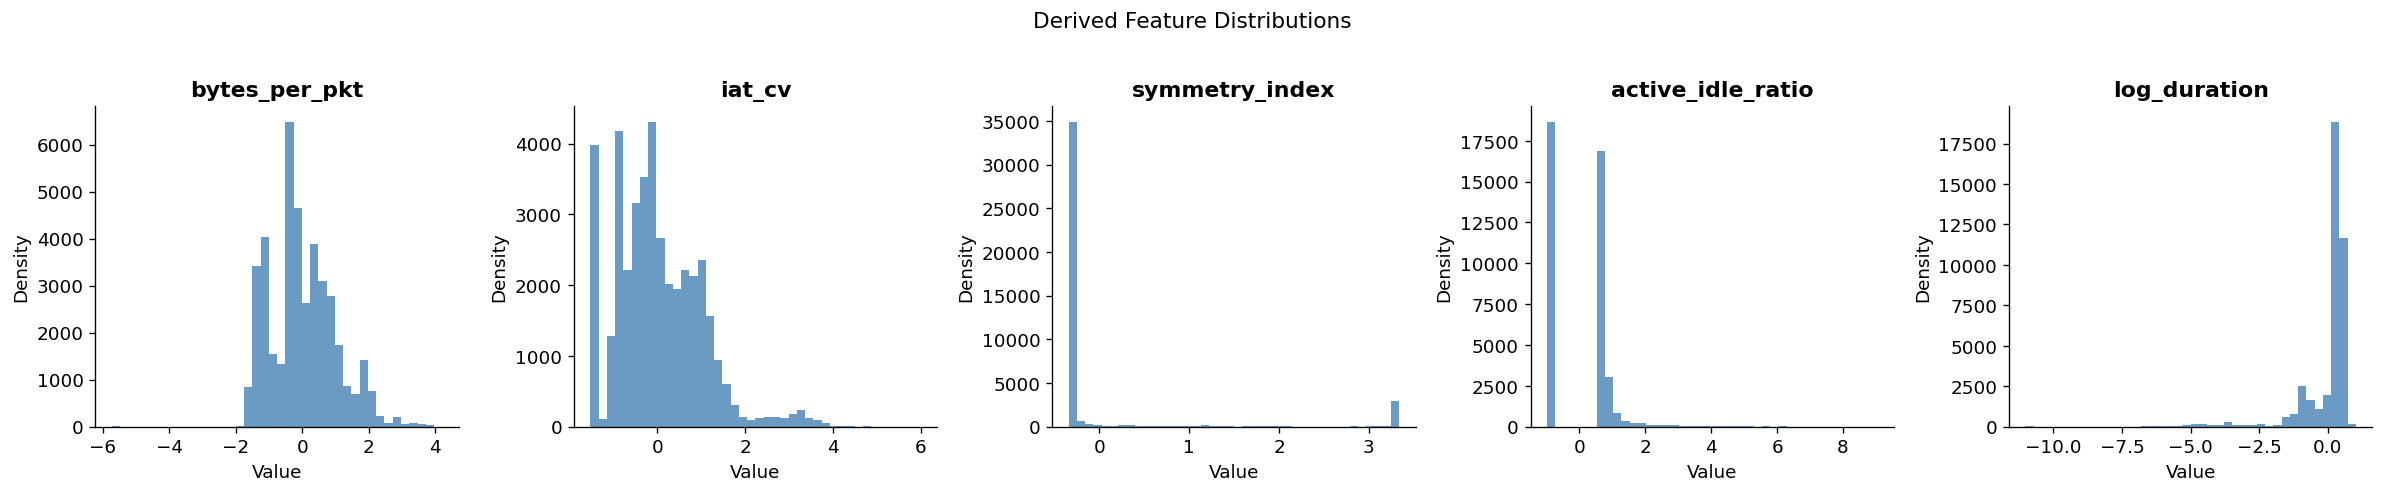

In [10]:
_new_features = [f for f in ["bytes_per_pkt", "iat_cv", "symmetry_index",
                               "active_idle_ratio", "log_duration"]
                 if f in df.columns]

_target_in_df = target_column in df.columns

if _new_features:
    fig, axes = plt.subplots(1, len(_new_features), figsize=(4 * len(_new_features), 4))
    if len(_new_features) == 1:
        axes = [axes]

    for ax, feat in zip(axes, _new_features):
        if _target_in_df and df[target_column].nunique() <= 15:
            for label in df[target_column].unique():
                subset = df[df[target_column] == label][feat]
                ax.hist(subset, bins=40, alpha=0.55, label=str(label), density=True)
            ax.legend(fontsize=8, title=target_column)
        else:
            ax.hist(df[feat], bins=40, color="steelblue", alpha=0.8)
        ax.set_title(feat, fontweight="bold")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")

    plt.suptitle("Derived Feature Distributions", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No derived features found to visualise.")